In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils

In [99]:
import numpy as np

In [100]:
import gudhi
from gudhi import hera
# import ot

In [101]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import plotly
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe'

## Vineyard Distance

In [102]:
def persistence(array, dimension=None):
  height, width = array.shape
  cubeComplex = gudhi.CubicalComplex(
      dimensions = [width,height],
      top_dimensional_cells = 255 - array.flatten()
  )
 
  if dimension == None:
    persistence = cubeComplex.persistence()
  else:
    cubeComplex.compute_persistence()
    persistence = cubeComplex.persistence_intervals_in_dimension(dimension)
    
  return persistence

In [103]:
def stitch(PDs, ts):
    vines = [[0, None, [x,]] for x in range(len(PDs[0]))]
    ends = {x:x for x in range(len(PDs[0]))}
    
    for i in range(1, len(ts)):
        dist, match = gudhi.hera.wasserstein_distance(PDs[i-1], PDs[i], matching=True)
    
        baby = []
        # print("IIII", i)
    
        new_ends = {k:ends[k] for k in ends}
        for j, (x, y) in enumerate(match):
            # print(x,y)
            if x == -1:
                baby.append(j)
            elif y == -1: # end vines
                vines[ends[x]][1] = i
                vines[ends[x]][2].append(-1)
                # print(f"end {x} -> -1")
            else: # update vines
                vines[ends[x]][2].append(y)
                new_ends[y] = ends[x]
                # print(f"join {x} -> {y} (ind {ends[x]})")
        
        # new vines
        for j in baby:
            x, y = match[j]
            new_ends[y] = len(vines)
            vines.append([i, None, [y,]])
            # print(f"new {y} -> *")
    
        for k in [l for l in ends]: 
            if k >= len(PDs[i]):
                del new_ends[k]
    
        ends = new_ends

    return vines

In [136]:
def vineyard(ts, hs, dim=1, verbose=0):
    PD0 = [persistence(h, dimension=dim) for h in hs]
    vines = stitch(PD0, ts)

    poss = vines
    
    for i,_ in enumerate(vines):
        # print("II", i, vines[i])
        # print(i, vines[i][2], PD0[0][])
        repl = []
        for j,x in enumerate(vines[i][2]):
            if x == -1:
                # print(PD0[vines[i][0]+j-1][vines[i][2][j-1]], "xx")
                repl.append(np.mean(PD0[vines[i][0]+j-1][vines[i][2][j-1]])*np.ones((2,))) # proj prev
            else:
                repl.append(PD0[vines[i][0]+j][x])
    
        poss[i][2] = np.array(repl)

    res = [[[ts[p[0]+np.arange(len(p[2]))][i], *x] for i,x in enumerate(p[2])] for p in poss]
    mx = np.max([np.max(p[2]) for p in poss if np.inf not in p[2]])

    if verbose > 0:
        gos = []
        
        for vine in res:
            vine = np.array(vine)
            # print(vine)
            gos.append(go.Scatter3d(x=vine[:,0], y=vine[:,1], z=vine[:,2], marker=dict(
                size=2,
            ),
            line=dict(
                width=2
            )))
        
        xs = np.linspace(0, mx, 10)
        zs = np.linspace(0, 1, 10)
        xss, zss = np.meshgrid(xs, zs)
        gos.append(go.Surface(x=zss, y=xss, z=xss, colorscale=[[0, '#333'], [1, '#333']], opacity=0.1, showscale=False)) # x - y = 0: diag plane
        
        fig = go.Figure(data=gos)
        
        fig.update_layout(
            width=800,
            height=700,
            scene=dict(
              xaxis_title='T (homotopy)',
              yaxis_title='Birth',
              zaxis_title='Death'
          )
        )
        
        fig.show()

    if verbose > 1:
        gudhi.plot_persistence_diagram(persistence(hs[len(ts)-1]))
        plt.show()
        gudhi.plot_persistence_diagram(persistence(hs[0]))
        plt.show()

    return res

In [105]:
def vdist(vines, fD, fL): # diag weight func, length weight func
    V = 0
    for vine in vines:
        vine = np.array(vine)
    
        v, L = 0, 0
        for i in range(1, len(vine)):
            l = np.linalg.norm(vine[i][1:]-vine[i-1][1:])
            dt = vine[i][0] - vine[i-1][0]
    
            mid = np.mean([vine[i][1:],vine[i-1][1:]], axis=0)
            proj = np.mean(mid)*np.ones(2,)
            D = np.linalg.norm(proj-mid)
            
            v += fD(D)*l*dt
            L += l*dt
    
        v *= fL(L)
        V += v

    return V

## VAE

In [112]:
batch_size = 128
latent_size = 20
epochs = 20
learning_rate = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [117]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_loader = DataLoader(
    datasets.MNIST('../data', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True)


In [156]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Linear(200, latent_size*2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # Sigmoid activation to output probabilities
        )
        
    def forward(self, x):
        # Flatten input images
        x = x.view(-1, 784)
        
        # Encode
        h = self.encoder(x)
        mu, logvar = torch.chunk(h, 2, dim=1)
        
        # Reparameterization trick
        z = self.reparameterize(mu, logvar)
        
        # Decode
        x_recon = self.decoder(z)
        
        return x_recon, mu, logvar

In [157]:
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Linear(200, latent_size)  # 2 for mean and variance
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # Sigmoid activation to output probabilities
        )

    def forward(self, x):
        # Flatten input images
        x = x.view(-1, 784)
        
        h = self.encoder(x)
        
        x_recon = self.decoder(h)
        
        return x_recon

In [200]:
class PCA(nn.Module):
    def __init__(self):
        super(PCA, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, latent_size, bias=False),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 784, bias=False),
        )

    def forward(self, x):
        # Flatten input images
        x = x.view(-1, 784)
        
        h = self.encoder(x)
        
        x_recon = self.decoder(h)
        
        return x_recon

In [207]:
model = PCA().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def loss_function(recon_x, x, mu=None, logvar=None):
    # BCE = nn.BCELoss(reduction='sum')(recon_x, x.view(-1, 784))
    # return BCE

    MSE = nn.MSELoss(reduction='sum')(recon_x, x.view(-1, 784))
    return MSE
    
    # KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # return BCE + KLD

In [208]:
def train(model, optimizer, train_loader, epochs):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            
            #recon_batch, mu, logvar = model(data)
            #loss = loss_function(recon_batch, data, mu, logvar)

            recon_batch = model(data)
            loss = loss_function(recon_batch, data)
            
            loss.backward()
            total_loss += loss.item()
            optimizer.step()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}, Loss: {loss.item()/len(data)}")

        print(f"====> Epoch {epoch+1}/{epochs}, Average Loss: {total_loss / len(train_loader.dataset)}")

train(model, optimizer, train_loader, epochs)

Epoch 1/20, Batch 0, Loss: 96.71956634521484
Epoch 1/20, Batch 100, Loss: 47.334415435791016
Epoch 1/20, Batch 200, Loss: 38.22348403930664
Epoch 1/20, Batch 300, Loss: 31.769845962524414
Epoch 1/20, Batch 400, Loss: 28.501686096191406
====> Epoch 1/20, Average Loss: 40.27866444498698
Epoch 2/20, Batch 0, Loss: 26.269454956054688
Epoch 2/20, Batch 100, Loss: 24.906742095947266
Epoch 2/20, Batch 200, Loss: 21.976699829101562
Epoch 2/20, Batch 300, Loss: 21.81222152709961
Epoch 2/20, Batch 400, Loss: 21.78426742553711
====> Epoch 2/20, Average Loss: 23.04789865722656
Epoch 3/20, Batch 0, Loss: 20.192142486572266
Epoch 3/20, Batch 100, Loss: 20.76357650756836
Epoch 3/20, Batch 200, Loss: 20.736896514892578
Epoch 3/20, Batch 300, Loss: 18.991003036499023
Epoch 3/20, Batch 400, Loss: 18.58841323852539
====> Epoch 3/20, Average Loss: 19.783408935546873
Epoch 4/20, Batch 0, Loss: 19.077533721923828
Epoch 4/20, Batch 100, Loss: 19.029199600219727
Epoch 4/20, Batch 200, Loss: 18.455881118774414

In [209]:
torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),}, 'pca_model.pth')
# checkpoint = torch.load('vae_model.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

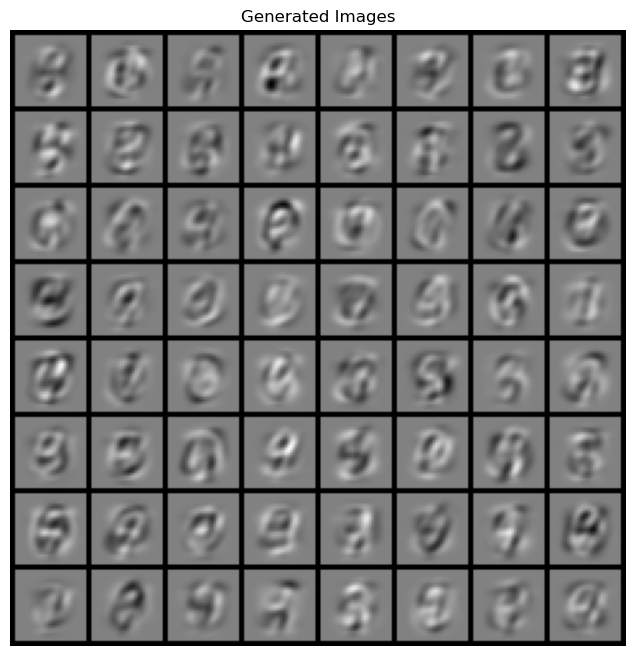

In [210]:
def generate_samples(model, num_samples):
    with torch.no_grad():
        z = torch.randn(num_samples, latent_size).to(device)
        samples = model.decoder(z).cpu()
        samples = samples.view(-1, 1, 28, 28)
        return samples

# Generate and visualize samples
samples = generate_samples(model, 64)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images")
plt.imshow(np.transpose(vutils.make_grid(samples, padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()


In [211]:
with open('h_end.npy', 'rb') as file:
    ends = torch.tensor(np.load(file)/255., dtype=torch.float32)

In [212]:
with torch.no_grad():
    embeds = model.encoder(ends.view(-1, 784))

In [213]:
def h_embed(t):
    with torch.no_grad():
        latent = (1-t)*embeds[0:1]+t*embeds[1:2]
        #mu, logvar = torch.chunk(latent, 2, dim=1)
        #z = model.reparameterize(mu, logvar)
        z = latent
        return model.decoder(z).cpu().view(-1, 1, 28, 28)[0,0]
    

In [248]:
ts = np.linspace(0, 1, 100)
hs = [h_embed(t) for t in ts]

In [249]:
stdze = lambda h: (h-torch.min(h))/(torch.max(h)-torch.min(h))
hs = [stdze(h) for h in hs]

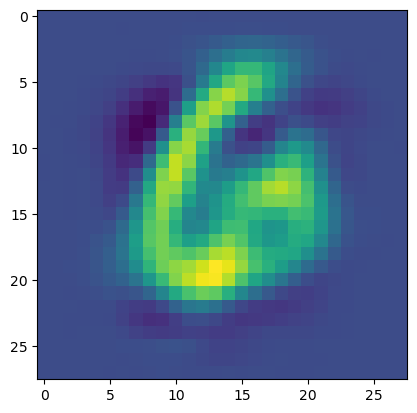

In [250]:
fig, ax = plt.subplots()
im = ax.imshow(hs[0], cmap='viridis', interpolation='nearest')

def init():
    im.set_data(hs[0])
    return [im]

def upd(i):
    im.set_data(hs[i])
    return [im]

ani = FuncAnimation(fig, upd, frames=range(len(ts)),
                    init_func=init, blit=True)

In [251]:
from IPython.display import HTML
HTML(ani.to_html5_video())

In [252]:
with open('hs69.npy', 'wb') as f:
    np.save(f, np.array(hs))



In [18]:
from IPython.display import HTML
HTML(ani.to_html5_video())

## Experiment

In [253]:
fD = lambda D: 1
fL = lambda L: 1

In [254]:
vines = vineyard(ts, np.array(hs)*255, dim=1, verbose=1)
vdist(vines, fD, fL)

10.961909704654007

In [199]:
hsN = np.array([t*(ends[0]*255)+(1-t)*(ends[1]*255) for t in ts]) 
vines = vineyard(ts, hsN, dim=1, verbose=1)
vdist(vines, fD, fL)

9.706916502545209